## Breast Cancer Diagnostic Classification

### Importing main libraries

In [603]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

### Configuring the default styling for all plots
(Specific styles can be applied to individual plots as needed.)

In [604]:
plt.rcParams['figure.figsize'] = [8, 6] # Width and height in inches
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['lines.linewidth'] = 1.3 # For plots with lines # Default
plt.rcParams['lines.markersize'] = 6 # For plots with markers (e.g. scatter plot)
plt.rcParams['axes.linewidth'] = 1 # Width of the border of the plot
plt.rcParams['axes.edgecolor'] = 'grey' # Colour of the border of the plot
plt.rcParams['axes.titlepad'] = 20 # Padding between title and plot
plt.rcParams['axes.labelpad'] = 10 # Padding between axis label and plot

# Colour cycle
color_list = ['darkblue', 'darkred', 'darkgreen', 'darkorange']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=color_list) 

# Enable and style grid lines for better data visualisation
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['axes.axisbelow'] = True # Ensure grid lines are behind plot elements

# Display plots inline directly below the relevant code cells so that plt.show() is not required
%matplotlib inline

### Loading the data

In [605]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

# Create a dataframe for the 30 features
X = pd.DataFrame(data.data, columns=data.feature_names)
# Create a series for the target (i.e. a class vector containing 569 labels)
y = pd.Series(data.target, name='target')

### D1 and D2

#### 1. Processing the dataset

In [606]:
# Combine the features and target into a single dataframe
df = pd.concat([X, y], axis=1)

# Reorder the columns based on column names
df_sorted = df.sort_index(axis=1)

#### 2. Plotting a 10x10 grid plot

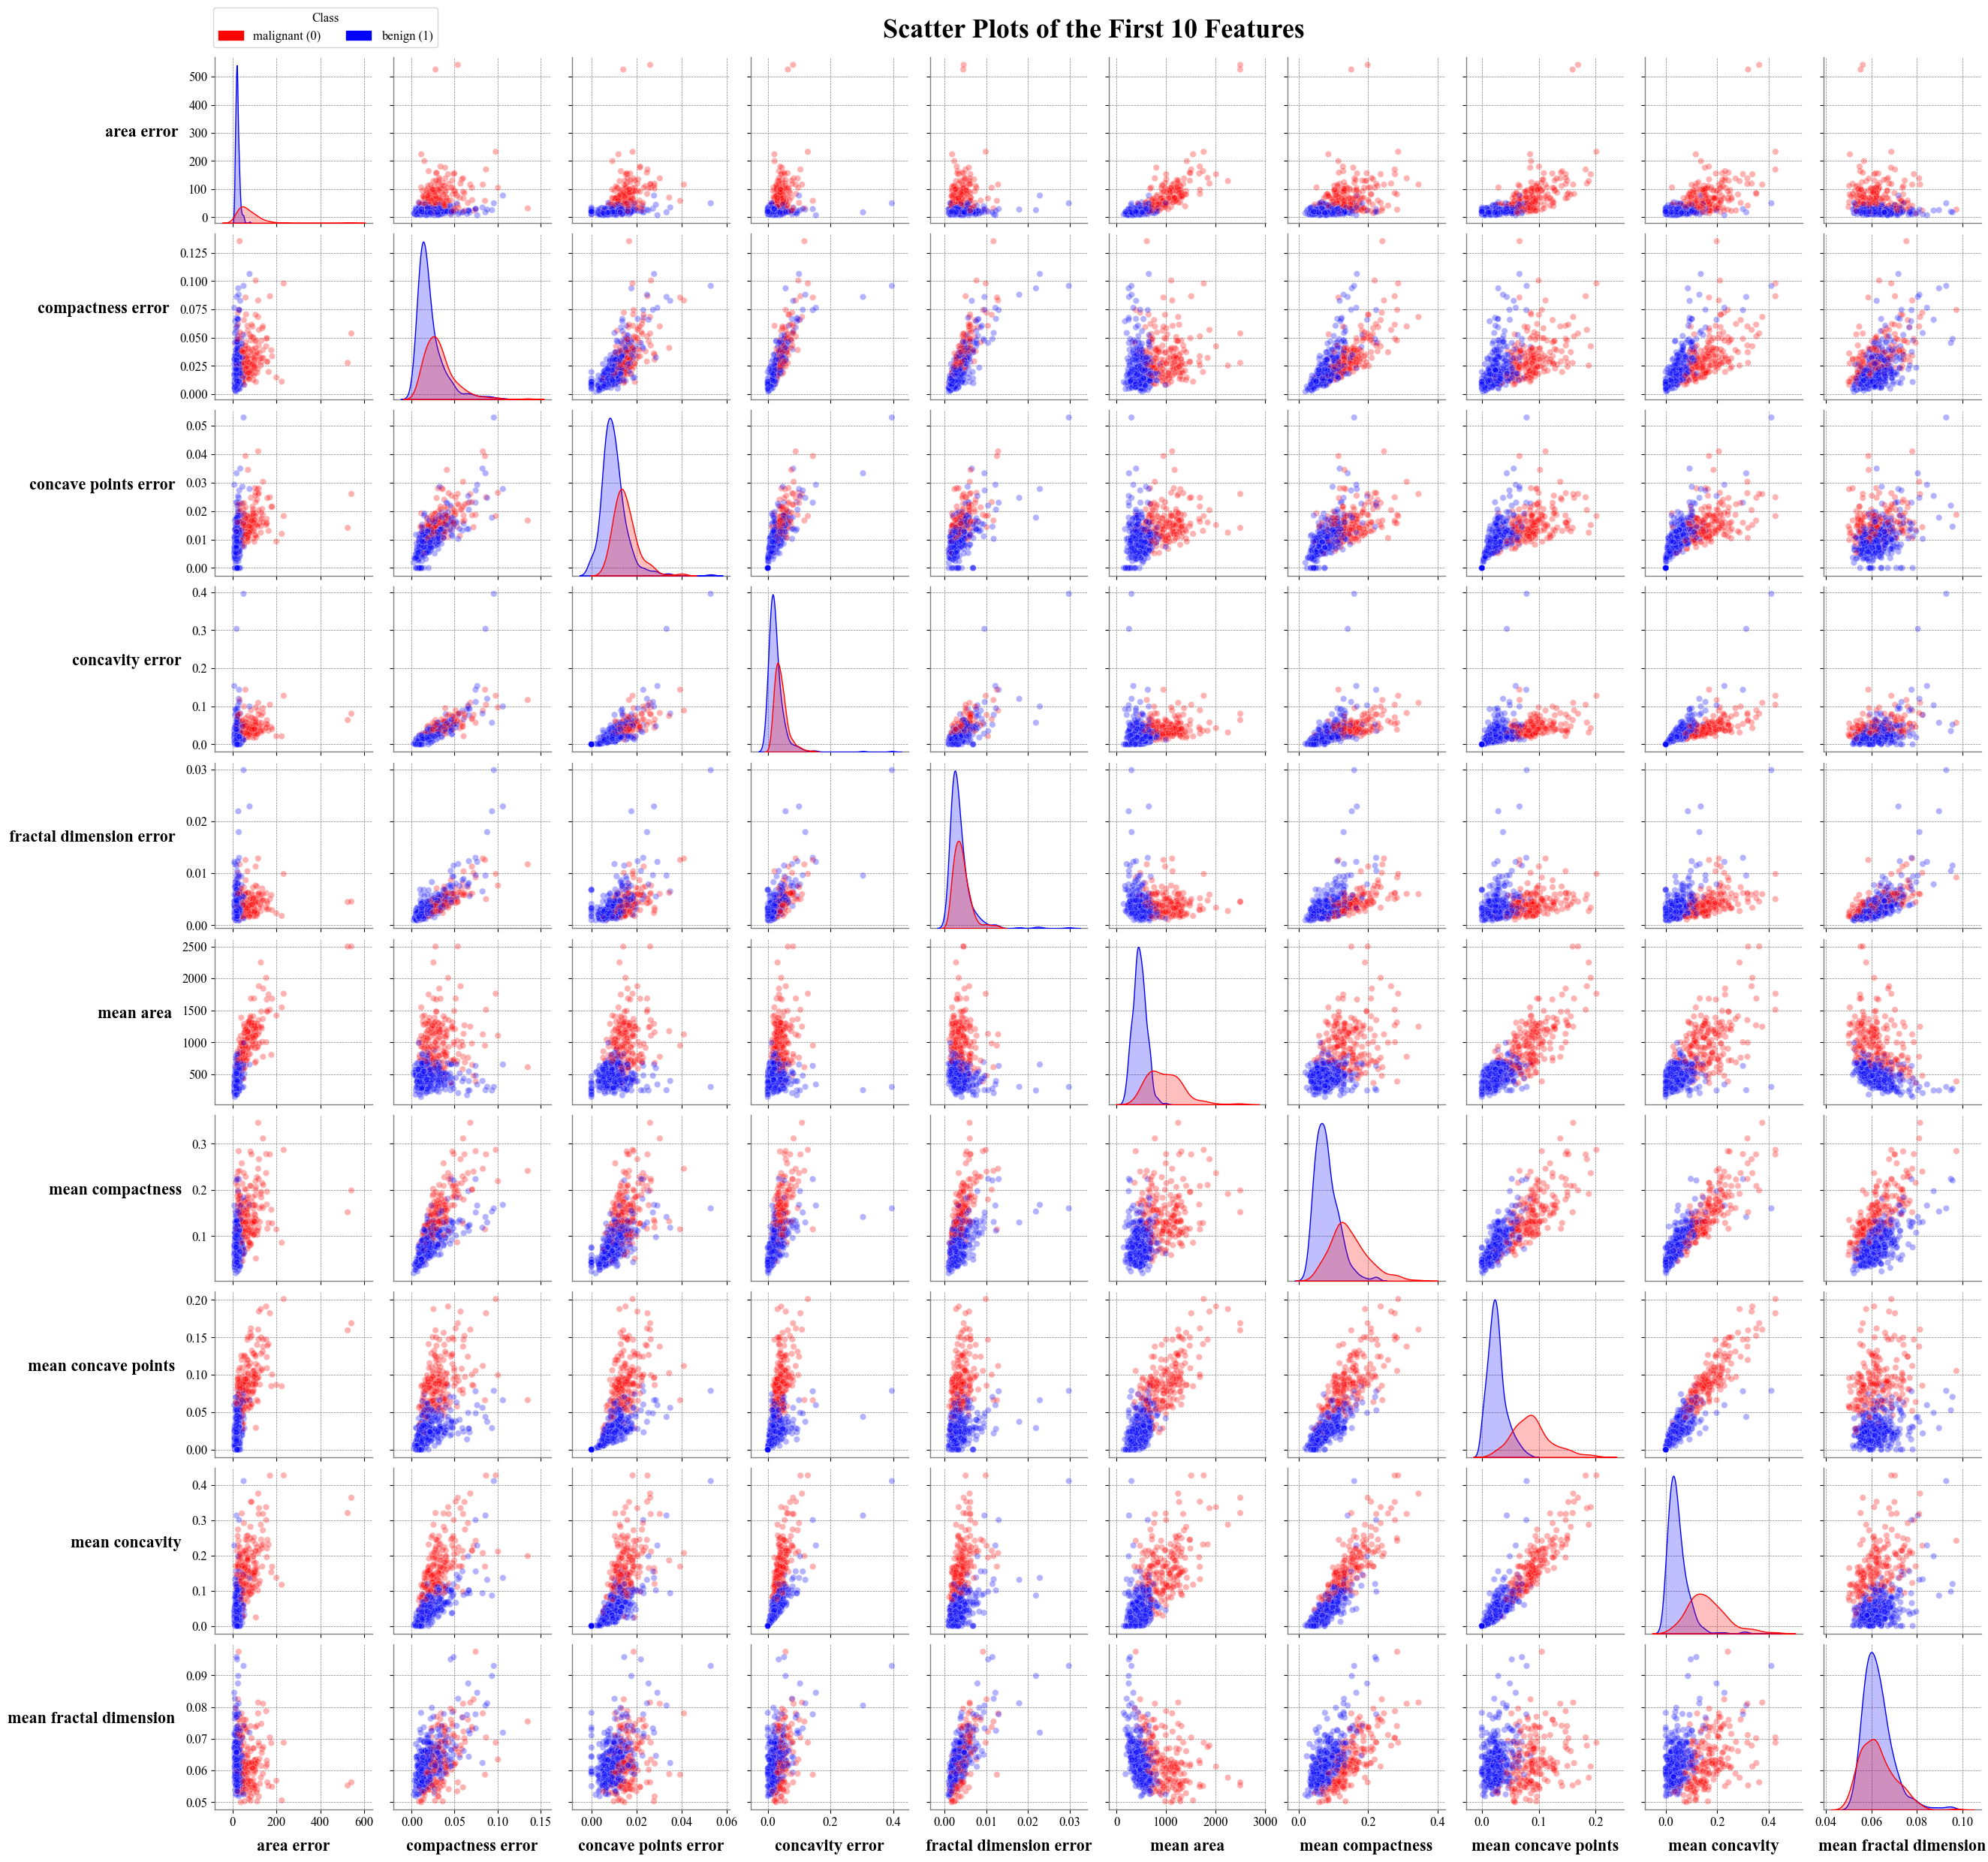

In [607]:
import matplotlib.patches as mpatches

# Plot scatter plots for the first 10 features using seaborn's pairplot (a 10x10 grid)
grid = sb.pairplot(df_sorted, vars=df_sorted.columns[:10], hue='target', palette={0: 'red', 1: 'blue'}, diag_kind='kde', plot_kws={'alpha': 0.3})
# hue='target': colour the data points based on the target class
# diag_kind='kde': display kernel density estimates (good for comparing distributions) on the diagonal
# plot_kws={'alpha': 0.3}: lower the transparency of the data points to better visualise overlapping points

# Remove the existing legend
grid._legend.remove()

# Create custom patches for the legend
red_patch = mpatches.Patch(color='red', label='malignant (0)')
blue_patch = mpatches.Patch(color='blue', label='benign (1)')

# Add the custom legend to the plot
plt.figlegend(handles=[red_patch, blue_patch], loc='upper left', ncol=2, labelspacing=0.5, title='Class', bbox_to_anchor=(0.04, 1))

# Adjust the top parameter to make some spaces for the legend
plt.subplots_adjust(top=0.97)

# Increase the size of x and y axis labels
for ax in grid.axes.flatten():
  ax.set_xlabel(ax.get_xlabel(), fontsize=16, fontweight='bold', labelpad=10)
  ax.set_ylabel(ax.get_ylabel(), fontsize=16, fontweight='bold', ha='right', rotation=0)

grid.figure.suptitle('Scatter Plots of the First 10 Features', fontsize=26, fontweight='bold', y=0.99);

### D3 and D4

#### Correlation Matrix

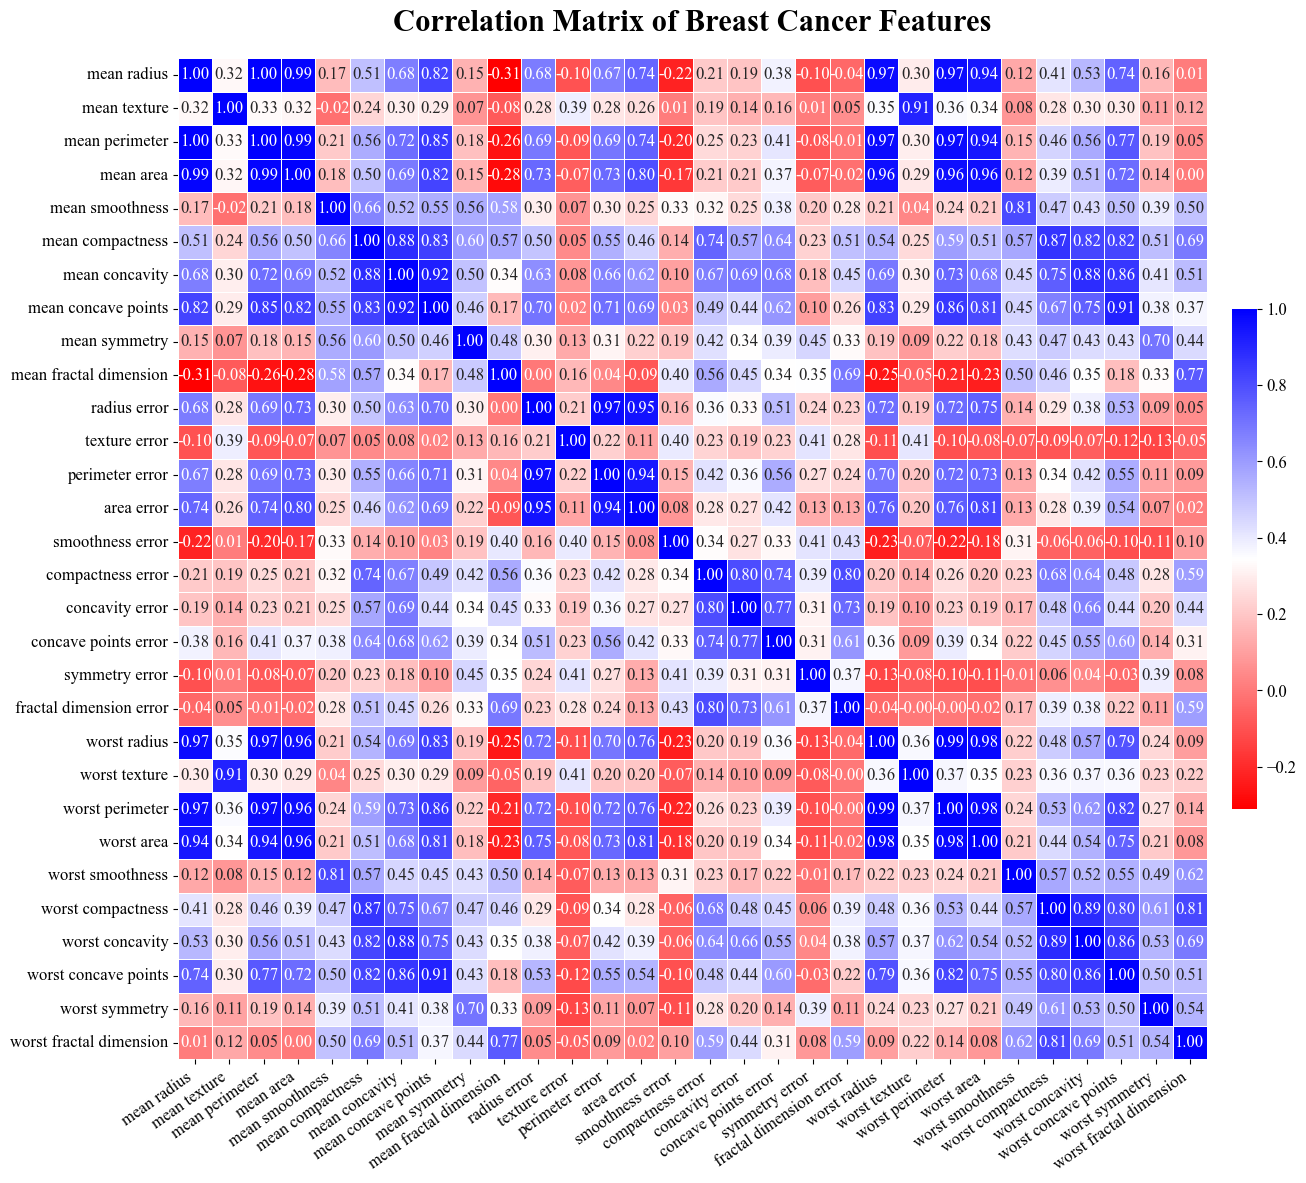

In [608]:
# Compute the correlation matrix
correlation_matrix = X.corr()

# Create a heatmap to visualise the matrix
plt.figure(figsize=(16, 13))
heatmap = sb.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='bwr_r', linewidths=0.6, cbar_kws={'shrink': 0.5, 'pad': 0.02})
plt.title('Correlation Matrix of Breast Cancer Features', fontsize=22, fontweight='bold')

# Rotate x-axis labels
plt.xticks(rotation=35, ha='right'); # ha='right': Align the end of label text to be close to x-axis

### D5

#### Dropping features with high correlation

In [609]:
# List of features to be dropped due to high correlation (> 0.97)
features_to_drop = ['mean perimeter', 'mean radius', 'worst radius', 'worst perimeter', 'radius error']

# Drop these features from the dataframe
df_sorted = df_sorted.drop(columns=features_to_drop)

# Check the updated dataframe to ensure it now contains 25 features (i.e. 26 columns including the target)
print('Updated dataframe:', df_sorted.shape)

# Update the feature matrix X accordingly
X = df_sorted.drop('target', axis=1)
print('Updated feature matrix X:', X.shape)

Updated dataframe: (569, 26)
Updated feature matrix X: (569, 25)


### D6 and D7

#### 1. Splitting the data

In [610]:
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5508)

#### 2. Fitting a Decision Tree Classifier and performing predictions

In [611]:
from sklearn.tree import DecisionTreeClassifier

# Initialise a Decision Tree Classifier with default parameters
dtc = DecisionTreeClassifier(random_state=5508)

# Fit the classifier on the training set
dtc.fit(X_train, y_train)

# Perform predictions on the training set and test set
y_train_pred = dtc.predict(X_train)
y_test_pred = dtc.predict(X_test)

#### 3. Evaluating model performance

In [612]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Calculate accuracy, precision, and recall for the training set
accuracy_train = round(accuracy_score(y_train, y_train_pred), 2)
precision_train = round(precision_score(y_train, y_train_pred), 2)
recall_train = round(recall_score(y_train, y_train_pred), 2)

# Calculate accuracy, precision, and recall for the test set
accuracy_test = round(accuracy_score(y_test, y_test_pred), 2)
precision_test = round(precision_score(y_test, y_test_pred), 2)
recall_test = round(recall_score(y_test, y_test_pred), 2)

# Calculate confusion matrix for the test set
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Print the results
print('Scores for the training set:')
print('Accuracy:', accuracy_train)
print('Precision:', precision_train)
print('Recall:', recall_train)

print('\nScores for the test set :')
print('Accuracy:', accuracy_test)
print('Precision:', precision_test)
print('Recall:', recall_test)

print('\nConfusion Matrix for the test Set:')
# Create a dataframe for adding class labels to the matrix
conf_matrix_df = pd.DataFrame(conf_matrix, index=[f'Actual {name}' for name in data.target_names], columns=[f'Predicted {name}' for name in data.target_names])
print(conf_matrix_df)

Scores for the training set:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0

Scores for the test set :
Accuracy: 0.96
Precision: 0.97
Recall: 0.97

Confusion Matrix for the test Set:
                  Predicted malignant  Predicted benign
Actual malignant                   39                 2
Actual benign                       2                71


### D8

#### Visualising Decision Tree

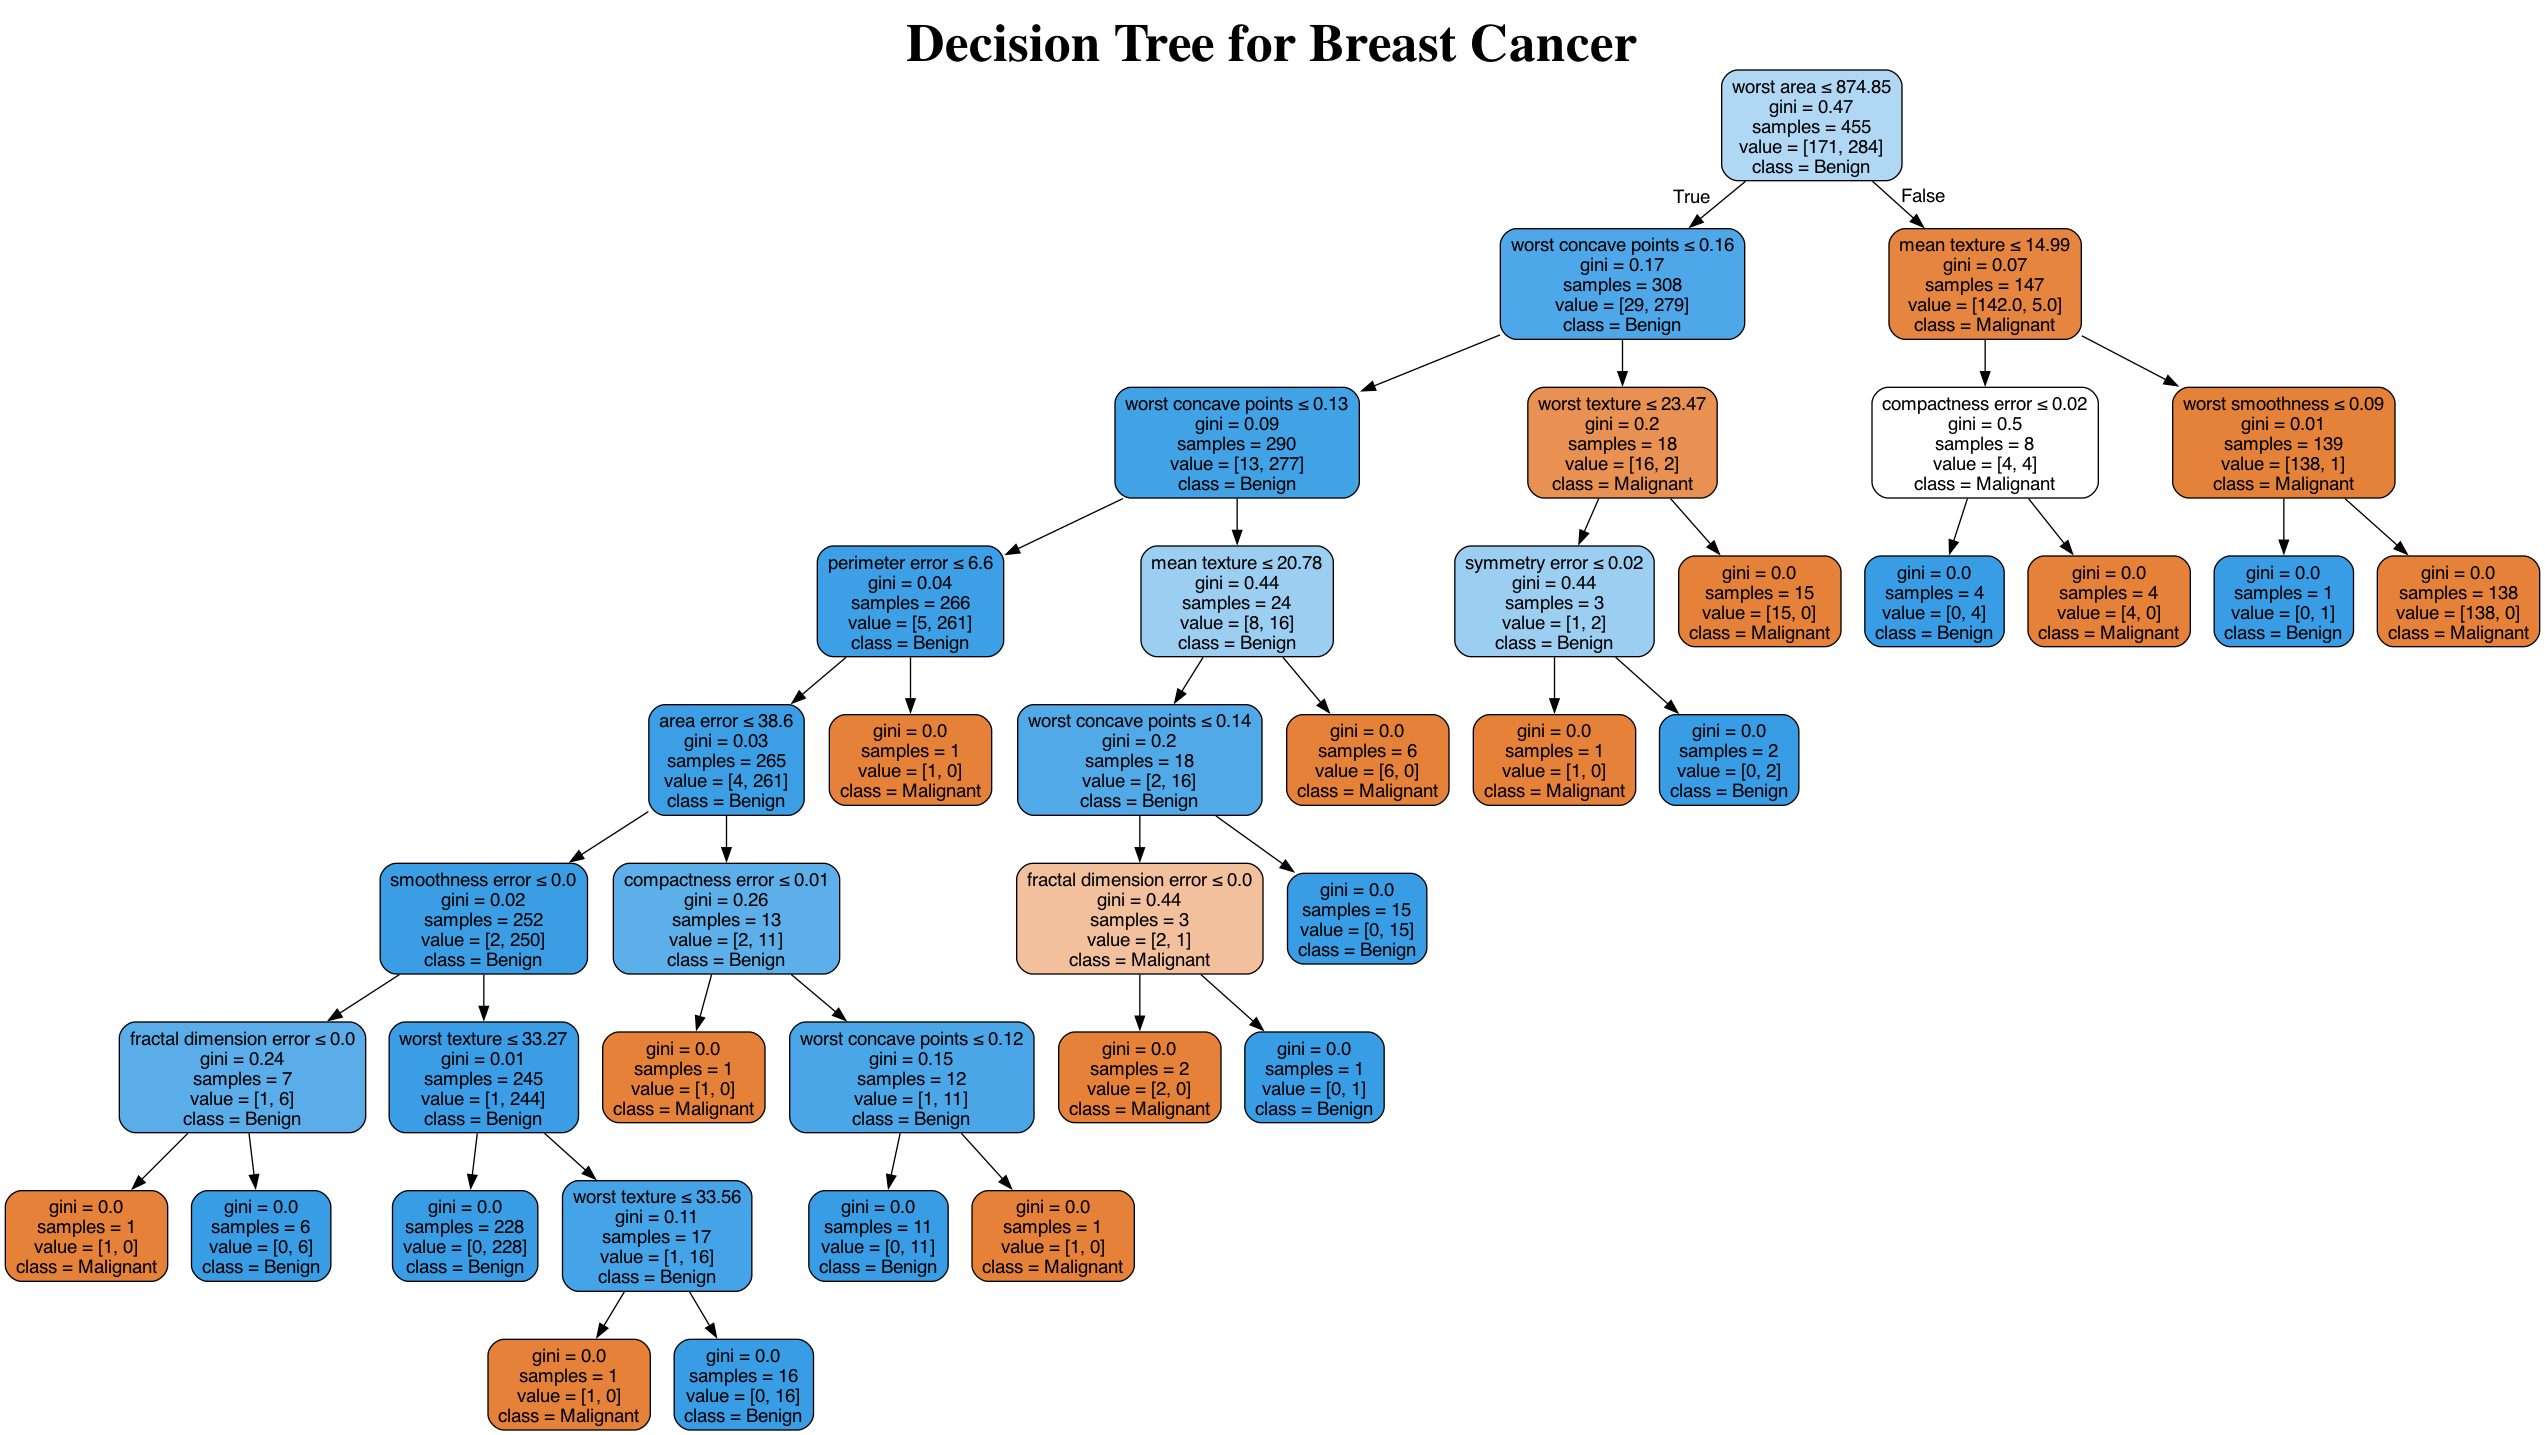

In [613]:
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import display, Image

# Export the decision tree to a dot format
dot_data = export_graphviz(
  dtc,
  out_file=None,
  feature_names=X.columns,
  class_names=['Malignant', 'Benign'],
  filled=True,
  rounded=True,
  special_characters=True,
  proportion=False, # Show the number of samples in each node
  leaves_parallel=False, # Display the leaves at the same level
  impurity=True, # Show the impurity (gini value) of each node
  label='all', # Show all the information in each node
  precision=2) # Set the number of decimal places to 2

# Add a custom title to the dot data manually
title = 'label="Decision Tree for Breast Cancer"; fontsize=40; fontname="bold"; labelloc="t";'
dot_data = 'digraph {' + title + dot_data[dot_data.find('{') + 1:]

# Create a graph from the dot data using Graphviz
graph = graphviz.Source(dot_data)

# Render the graph to a PNG image
image_data = graph.pipe(format='png')

# Display the image in Jupyter Notebook
display(Image(image_data))


### D9

#### Counting the number of tree levels

In [614]:
tree_depth = dtc.get_depth()

print(f'The number of levels in the Decision Tree is {tree_depth}.')

The number of levels in the Decision Tree is 8.


### D10

#### 1. Training and evaluating the model

In [615]:
# Seeds for the random states ("5508" previously used + four additional splits)
seeds = [5508, 5509, 5510, 5511, 5512]

# Lists to store the scores for plotting
accuracies = []
precisions = []
recalls = []

# Loop over each seed to split the data, train the model, and evaluate it
for seed in seeds:
  # Split the data
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
  
  # Initialise and fit the Classifier
  dtc = DecisionTreeClassifier(random_state=5508) # Keep the random state of the model at "5508"
  dtc.fit(X_train, y_train)
  
  # Perform predictions on the test set
  y_test_pred = dtc.predict(X_test)
  
  # Calculate scores and append to the lists for plotting
  accuracies.append(accuracy_score(y_test, y_test_pred))
  precisions.append(precision_score(y_test, y_test_pred))
  recalls.append(recall_score(y_test, y_test_pred))

#### 2. Plotting bar charts for the results

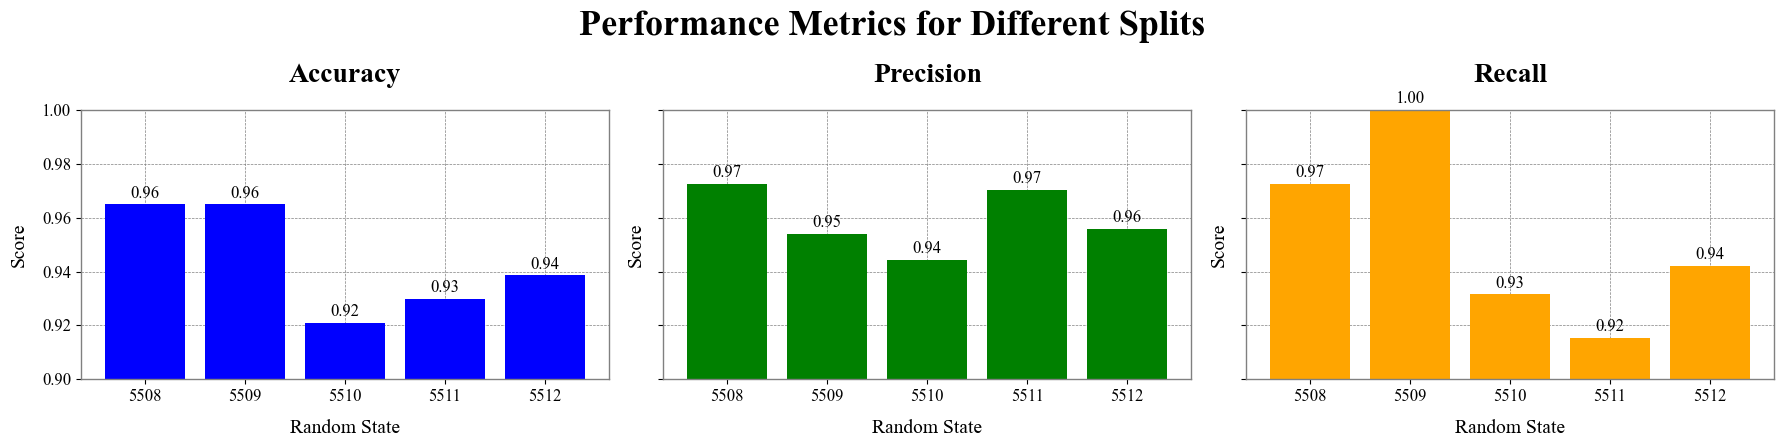

In [616]:
# Define a function to plot the metric
def plot_metric(data, ax, title, color, seeds):
  # Create bar charts
  ax.bar(range(len(seeds)), data, color=color)
  ax.set_title(title, fontsize=20, fontweight='bold')
  ax.set_xticks(range(len(seeds)))
  ax.set_xticklabels(seeds)
  ax.set_xlabel('Random State')
  ax.set_ylabel('Score')
  ax.set_ylim(0.9, 1) # Set the y-axis limits to be in the range of 0.9 to 1
  ax.set_yticks([i / 100 for i in range(90, 101, 2)]) # Set the y-ticks within the range of 0.9 to 1 with a step of 0.02

  # Add value labels on top of each bar
  for rect in ax.patches:
    y_pos = rect.get_height() # height of the bar
    x_pos = rect.get_x() + rect.get_width() / 2 # x-coordinate of the centre of the bar
    label = '{:.2f}'.format(y_pos)
    ax.annotate(label, (x_pos, y_pos), xytext=(0, 2), textcoords='offset points', ha='center', va='bottom') # Add the label and set alignments

# Plot the results by applying the function
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True) #sharey=True: share the y-axis limits and ticks
fig.suptitle('Performance Metrics for Different Splits', fontsize=26, fontweight='bold', y=0.92)

plot_metric(accuracies, axes[0], 'Accuracy', 'blue', seeds)
plot_metric(precisions, axes[1], 'Precision', 'green', seeds)
plot_metric(recalls, axes[2], 'Recall', 'orange', seeds)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust the layout to make space for the title

### D11

#### 1. Training and evaluating the model

In [617]:
# Define the different training-test splits
splits = [0.50, 0.60, 0.70, 0.80, 0.90]  # Percentages of data used for training

# Initialise the lists for storing results
accuracies = []
precisions = []
recalls = []

for split in splits:
  # Split the data
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1-split, random_state=5508)
  
  # Initialise and train the model
  dtc = DecisionTreeClassifier(random_state=5508)
  dtc.fit(X_train, y_train)
  
  # Evaluate the model
  y_pred = dtc.predict(X_test)
  accuracies.append(accuracy_score(y_test, y_pred))
  precisions.append(precision_score(y_test, y_pred))
  recalls.append(recall_score(y_test, y_pred))

#### 2. Plotting line charts for the results

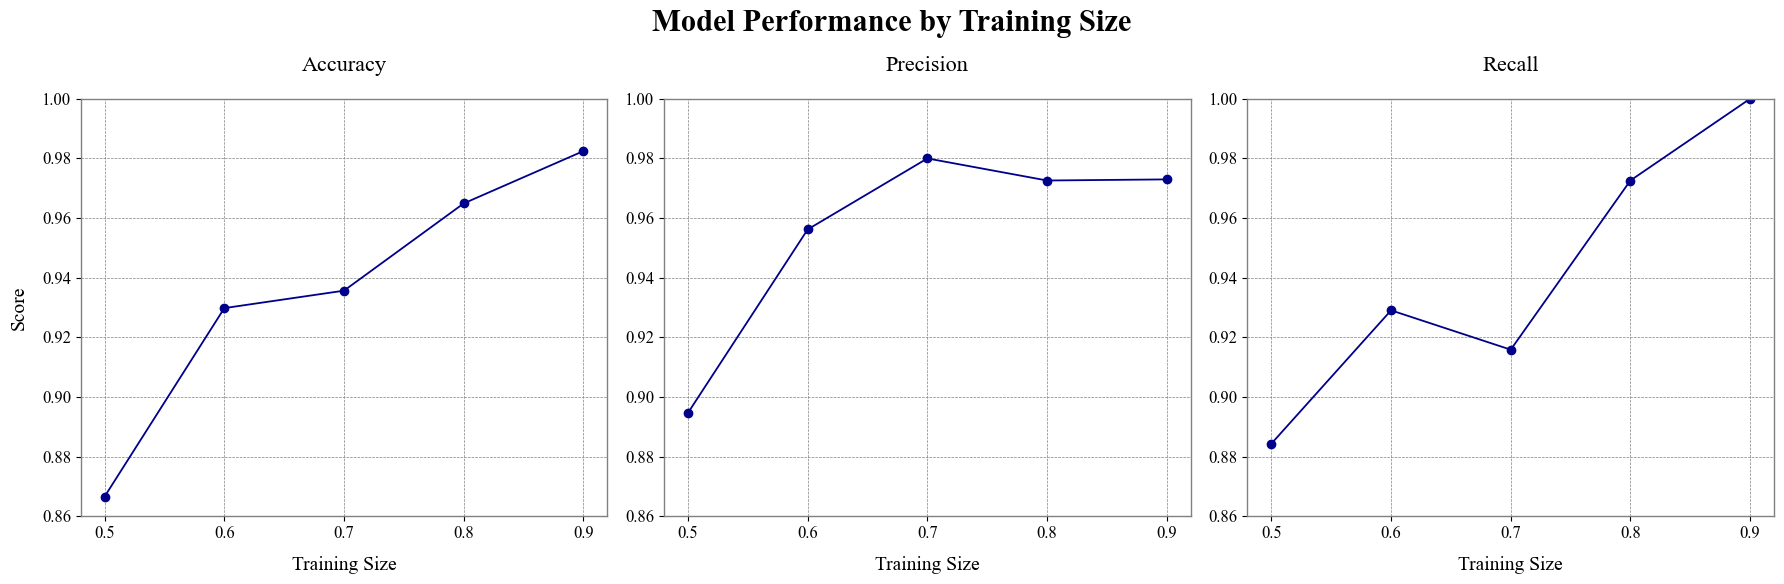

In [618]:
# Define a function to plot the metric
def plot_metric2(ax, data, title, x_label, y_label=None):
  ax.plot(splits, data, marker='o', linestyle='-')
  ax.set_title(title)
  ax.set_xlabel(x_label)
  if y_label:
    ax.set_ylabel(y_label)
  ax.set_ylim(0.86, 1) # Set the y-axis limits
  ax.set_yticks([i / 100 for i in range(86, 101, 2)]) # Set the y-ticks
  ax.set_xticks([0.5, 0.6, 0.7, 0.8, 0.9]) # Set the x-ticks

# Plot the results by applying the function
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance by Training Size', fontsize=22, fontweight='bold', y=0.97)

plot_metric2(axes[0], accuracies, 'Accuracy', 'Training Size', 'Score')
plot_metric2(axes[1], precisions, 'Precision', 'Training Size')
plot_metric2(axes[2], recalls, 'Recall', 'Training Size')

plt.tight_layout()

### D12 and D13

#### 1. Performing 10-fold Cross-Validation using Grid Search to find the optimal combination of hyperparameters

In [619]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5508)

# Define a dictionary for the given hyperparameters
param_grid = {
  'max_depth': [2, 3, 4, 5], # Maximum depth of the tree
  'min_samples_split': [2, 4, 5, 10], # Minimum number of samples required to split an internal node
  'min_samples_leaf': [2, 5] # Minimum number of samples required to be at a leaf node
}

# Initialise the classifier
dtc = DecisionTreeClassifier(random_state=5508)

# Set up the cross-validator with a random state of 42
# Since there is not a direct random_state parameter in GridSearchCV, use StratifiedKFold to set the random state
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Initialise the GridSearchCV object
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=cv, scoring='accuracy')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the optimal combination of hyperparameters
best_params = grid_search.best_params_
print('Optimal combination of hyperparameters:\n', best_params)

Optimal combination of hyperparameters:
 {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}


#### 2. Retraining and evaluating the model

In [620]:
# Retrain the model with the optimal hyperparameters
best_dtc = DecisionTreeClassifier(**best_params, random_state=5508) ## **best_params: unpack the dictionary
best_dtc.fit(X_train, y_train)

# Make predictions on the training and test sets
y_train_pred = best_dtc.predict(X_train)
y_test_pred = best_dtc.predict(X_test)

# Calculate scores for the training set
train_accuracy_full = round(accuracy_score(y_train, y_train_pred), 2)
train_precision_full = round(precision_score(y_train, y_train_pred), 2)
train_recall_full = round(recall_score(y_train, y_train_pred), 2)

# Calculate scores for the test set
test_accuracy_full = round(accuracy_score(y_test, y_test_pred), 2)
test_precision_full = round(precision_score(y_test, y_test_pred), 2)
test_recall_full = round(recall_score(y_test, y_test_pred), 2)

# Confusion matrix for the test set
conf_matrix = confusion_matrix(y_test, y_test_pred)
# Create a dataframe for adding class labels to the matrix
conf_matrix_full_df = pd.DataFrame(conf_matrix, index=[f'Actual {name}' for name in data.target_names], columns=[f'Predicted {name}' for name in data.target_names])

#### 3. Printing the results

In [621]:
print('\nScores for the training set:')
print('Accuracy:', train_accuracy_full)
print('Precision:', train_precision_full)
print('Recall:', train_recall_full)

print('\nScores for the test set:')
print('Accuracy:', test_accuracy_full)
print('Precision:', test_precision_full)
print('Recall:', test_recall_full)

print('\nConfusion Matrix for the test set:')
print(conf_matrix_full_df)


Scores for the training set:
Accuracy: 0.96
Precision: 0.95
Recall: 0.99

Scores for the test set:
Accuracy: 0.94
Precision: 0.96
Recall: 0.95

Confusion Matrix for the test set:
                  Predicted malignant  Predicted benign
Actual malignant                   38                 3
Actual benign                       4                69


### D14

#### Repeating D12 with two more scoring options

In [622]:
# Define the scoring options
scorings = ['accuracy', 'precision', 'recall']

# Initialise a dictionary for storing results
results = {}

# Perform Grid Search for each scoring metric
for scoring in scorings:
  # Initialise the classifier
  dtc = DecisionTreeClassifier(random_state=5508)

  # Initialise the GridSearchCV object
  grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=cv, scoring=scoring) # param_grid and cv were previously defined in D12

  # Fit GridSearchCV to the training data
  grid_search.fit(X_train, y_train)
  
  # Print the optimal combination of hyperparameters
  best_params = grid_search.best_params_
  print(f'Optimal combination of hyperparameters for {scoring}:\n', best_params)

  # Retrain the model with the optimal hyperparameters
  best_dtc = DecisionTreeClassifier(**best_params, random_state=5508)
  best_dtc.fit(X_train, y_train)
  
  # Make predictions on the test set
  y_test_pred = best_dtc.predict(X_test)

  # Calculate confusion matrix for the test set
  conf_matrix = confusion_matrix(y_test, y_test_pred)
  conf_matrix_df = pd.DataFrame(conf_matrix, index=[f'Actual {name}' for name in data.target_names], columns=[f'Predicted {name}' for name in data.target_names])
  
  # Print the results
  print(f'\nConfusion Matrix for {scoring} on the test set:')
  print(conf_matrix_df)
  print('\n')

Optimal combination of hyperparameters for accuracy:
 {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}

Confusion Matrix for accuracy on the test set:
                  Predicted malignant  Predicted benign
Actual malignant                   38                 3
Actual benign                       4                69


Optimal combination of hyperparameters for precision:
 {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}

Confusion Matrix for precision on the test set:
                  Predicted malignant  Predicted benign
Actual malignant                   39                 2
Actual benign                       4                69


Optimal combination of hyperparameters for recall:
 {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}

Confusion Matrix for recall on the test set:
                  Predicted malignant  Predicted benign
Actual malignant                   38                 3
Actual benign                       4               

### D15

#### Examining the feature importances of the accuracy-optimised model in D12

In [623]:
# Use the fine-tuned hyperparameters from D12
best_params = {'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}

# Initialise and train the Decision Tree Classifier
dtc = DecisionTreeClassifier(**best_params, random_state=5508)
dtc.fit(X_train, y_train)

# Get feature importances from the model
feature_importances = dtc.feature_importances_

# Create a dataframe to display the feature names and their importance scores
features_df = pd.DataFrame({
  'Feature': X.columns,
  'Importance': feature_importances
})

# Sort the dataframe by feature importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

# Print the feature importances
print(features_df)

                    Feature  Importance
17               worst area    0.801542
19     worst concave points    0.151040
10          mean smoothness    0.019469
12             mean texture    0.012717
24            worst texture    0.011775
13          perimeter error    0.003456
5                 mean area    0.000000
16            texture error    0.000000
23           worst symmetry    0.000000
22         worst smoothness    0.000000
21  worst fractal dimension    0.000000
20          worst concavity    0.000000
2      concave points error    0.000000
18        worst compactness    0.000000
3           concavity error    0.000000
15           symmetry error    0.000000
6          mean compactness    0.000000
14         smoothness error    0.000000
1         compactness error    0.000000
11            mean symmetry    0.000000
4   fractal dimension error    0.000000
9    mean fractal dimension    0.000000
8            mean concavity    0.000000
7       mean concave points    0.000000


### D16

#### Selecting features based on the feature importances

In [624]:
from sklearn.feature_selection import SelectFromModel

# Initialise the selector
selector = SelectFromModel(dtc, threshold=0.01)

# Refit the selector to avoid warnings about missing feature names
selector.fit(X_train, y_train)

# Transform the feature space to include only important features
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Get the names of the retained features
selected_features = X_train.columns[selector.get_support()] # .get_support() returns a boolean mask of the selected features (True: selected, False: removed)

# Calculate the total retained feature importance
total_importance = features_df[features_df['Feature'].isin(selected_features)]['Importance'].sum()

# Print the results
print('Retained features:', selected_features)
print('Removed features:', X.columns[~selector.get_support()]) # ~: bitwise NOT operator to invert the boolean mask
print('Total feature importance retained:', total_importance)

Retained features: Index(['mean smoothness', 'mean texture', 'worst area', 'worst concave points',
       'worst texture'],
      dtype='object')
Removed features: Index(['area error', 'compactness error', 'concave points error',
       'concavity error', 'fractal dimension error', 'mean area',
       'mean compactness', 'mean concave points', 'mean concavity',
       'mean fractal dimension', 'mean symmetry', 'perimeter error',
       'smoothness error', 'symmetry error', 'texture error',
       'worst compactness', 'worst concavity', 'worst fractal dimension',
       'worst smoothness', 'worst symmetry'],
      dtype='object')
Total feature importance retained: 0.9965437229287064


### D17 and D18

#### 1. Repeating the 10-fold Cross-Validation for the reduced feature set to find the optimal hyperparameters

In [625]:
# Create the reduced feature set by selecting only the important features
X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]

# Repeat the cross-validation for the reduced feature set
dtc_reduced = DecisionTreeClassifier(random_state=5508)
grid_search_reduced = GridSearchCV(estimator=dtc_reduced, param_grid=param_grid, cv=cv, scoring='accuracy') # param_grid and cv were previously defined in D12
grid_search_reduced.fit(X_train_reduced, y_train)
best_params_reduced = grid_search_reduced.best_params_
print(f'Optimal hyperparameters for the reduced feature set (based on accuracy):\n', best_params_reduced)

Optimal hyperparameters for the reduced feature set (based on accuracy):
 {'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 5}


#### 2. Training and evaluating the model

In [626]:
# Train the model with reduced features using the fine-tuned hyperparameters
dtc_reduced = DecisionTreeClassifier(**best_params_reduced, random_state=5508)
dtc_reduced.fit(X_train_reduced, y_train)

# Make predictions on the training and test sets
y_train_pred_reduced = dtc_reduced.predict(X_train_reduced)
y_test_pred_reduced = dtc_reduced.predict(X_test_reduced)

# Evaluate the model
train_accuracy_reduced = round(accuracy_score(y_train, y_train_pred_reduced), 2)
train_precision_reduced = round(precision_score(y_train, y_train_pred_reduced), 2)
train_recall_reduced = round(recall_score(y_train, y_train_pred_reduced), 2)
test_accuracy_reduced = round(accuracy_score(y_test, y_test_pred_reduced), 2)
test_precision_reduced = round(precision_score(y_test, y_test_pred_reduced), 2)
test_recall_reduced = round(recall_score(y_test, y_test_pred_reduced), 2)
conf_matrix_reduced = confusion_matrix(y_test, y_test_pred_reduced)

#### 3. Formatting and printing the results

In [627]:
# Metrics for the two sets (with the scores for the full feature set from D12)
data_training = {
  'Feature Set': ['Full Features', 'Reduced Features'],
  'Accuracy': [train_accuracy_full, train_accuracy_reduced],
  'Precision': [train_precision_full, train_precision_reduced],
  'Recall': [train_recall_full, train_recall_reduced]
}

data_test = {
  'Feature Set': ['Full Features', 'Reduced Features'],
  'Accuracy': [test_accuracy_full, test_accuracy_reduced],
  'Precision': [test_precision_full, test_precision_reduced],
  'Recall': [test_recall_full, test_recall_reduced]
}

# Create dataframes for the scores
df_training = pd.DataFrame(data_training)
df_test = pd.DataFrame(data_test)

# Confusion matrix for the reduced feature set
conf_matrix_reduced_df = pd.DataFrame(conf_matrix_reduced, index=[f'Actual {name}' for name in data.target_names], columns=[f'Predicted {name}' for name in data.target_names])

# Print the results
print('Scores for the training set:')
display(df_training)
print('Scores for the test set:')
display(df_test)
print('Confusion Matrix for the test set (Full Features):\n', conf_matrix_full_df) # From D12
print('\nConfusion Matrix for the test set (Reduced Features):\n', conf_matrix_reduced_df)

Scores for the training set:


,Feature Set,Accuracy,Precision,Recall
0,Full Features,0.96,0.95,0.99
1,Reduced Features,0.98,0.97,0.99


Scores for the test set:


,Feature Set,Accuracy,Precision,Recall
0,Full Features,0.94,0.96,0.95
1,Reduced Features,0.95,0.97,0.95


Confusion Matrix for the test set (Full Features):
                   Predicted malignant  Predicted benign
Actual malignant                   38                 3
Actual benign                       4                69

Confusion Matrix for the test set (Reduced Features):
                   Predicted malignant  Predicted benign
Actual malignant                   39                 2
Actual benign                       4                69


### D19 and D20

#### 1. Performing 10-fold Cross-Validation using Grid Search to find the optimal combination of hyperparameters for a Random Forest classifier

In [628]:
from sklearn.ensemble import RandomForestClassifier

# Split the data with the specified random state "5508"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5508)

# Define the parameter grid for cross-validation
param_grid_rf = {
  'n_estimators': [10, 20, 50, 100, 1000], # Number of trees in the forest
  'max_depth': [2, 3, 4, 5] # Maximum depth of each tree
}

# Initialise the RandomForest classifier with the specified random state "5508"
rf = RandomForestClassifier(random_state=5508)

# Set up the cross-validator with the specified random state "42"
cv_rf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Initialise the GridSearchCV object
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=cv_rf, scoring='accuracy')

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

# Retrieve the optimal hyperparameters
best_params_rf = grid_search_rf.best_params_
print('Optimal hyperparameters for Random Forest:\n', best_params_rf)

Optimal hyperparameters for Random Forest:
 {'max_depth': 4, 'n_estimators': 100}


#### 2. Retraining and evaluating the model

In [629]:
# Retrain the model with the optimal parameters and specified random state
rf_optimal = RandomForestClassifier(**best_params_rf, random_state=5508)
rf_optimal.fit(X_train, y_train)

# Make predictions on the training and test sets
y_train_pred_rf = rf_optimal.predict(X_train)
y_test_pred_rf = rf_optimal.predict(X_test)

# Calculate scores for the training set
train_accuracy_rf = round(accuracy_score(y_train, y_train_pred_rf), 2)
train_precision_rf = round(precision_score(y_train, y_train_pred_rf), 2)
train_recall_rf = round(recall_score(y_train, y_train_pred_rf), 2)

# Calculate scores for the test set
test_accuracy_rf = round(accuracy_score(y_test, y_test_pred_rf), 2)
test_precision_rf = round(precision_score(y_test, y_test_pred_rf), 2)
test_recall_rf = round(recall_score(y_test, y_test_pred_rf), 2)

# Confusion matrix for the test set
conf_matrix_rf = confusion_matrix(y_test, y_test_pred_rf)
conf_matrix_rf_df = pd.DataFrame(conf_matrix_rf, index=[f'Actual {name}' for name in data.target_names], columns=[f'Predicted {name}' for name in data.target_names])

#### 3. Printing the results

In [630]:
print('\nScores for the training set:')
print('Accuracy:', train_accuracy_rf)
print('Precision:', train_precision_rf)
print('Recall:', train_recall_rf)

print('\nScores for the test set:')
print('Accuracy:', test_accuracy_rf)
print('Precision:', test_precision_rf)
print('Recall:', test_recall_rf)

print('\nConfusion Matrix for the test set:')
print(conf_matrix_rf_df)


Scores for the training set:
Accuracy: 0.99
Precision: 0.99
Recall: 1.0

Scores for the test set:
Accuracy: 0.98
Precision: 0.99
Recall: 0.99

Confusion Matrix for the test set:
                  Predicted malignant  Predicted benign
Actual malignant                   40                 1
Actual benign                       1                72
